# Jigsaw — latest system checkpoint

This notebook is the public, employer-facing checkpoint for the September 21, 2026 supervision experiment. It summarizes **verified aggregate evidence only**; no private comments, row-level predictions, AWS checkpoints, credentials, or hidden labels are included.

**Verified best:** support-adapted Qwen3-4B at **0.91808 public / 0.91425 private Kaggle AUC**.  
**Exploratory candidate:** the same 4B recipe with one deliberate change—strict-majority resolution of conflicting normalized rule/comment labels while ties remain excluded. Its official submission was **pending** at the captured snapshot, so this notebook does not claim a candidate AUC or promotion.

## Research question and experimental discipline

The project had already established that broad feature expansion can improve familiar-policy fit while failing to transfer to unseen policies. This experiment therefore changes **one major factor** instead of introducing another feature bank: how contradictory support supervision is resolved.

Earlier CPU proxy work rejected majority resolution under a fixed TF-IDF/Ridge representation. This direct end-to-end check asks a narrower question: **does the already-strong neural LoRA system respond differently when ten strict-majority conflicts are retained?** The candidate is exploratory, and the scored 4B model remains the reference until official evidence says otherwise.

In [1]:
from pathlib import Path
import json
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import SVG, display

ROOT = Path.cwd().resolve()
while not (ROOT / "reports/majority_submission/summary.json").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("project root not found")
    ROOT = ROOT.parent
summary = json.loads((ROOT / "reports/majority_submission/summary.json").read_text())
scored = summary["verified_scored_system"]
candidate = summary["candidate"]
audit = summary["supervision_audit"]
print(f"Verified private AUC: {scored['private_auc']:.5f}")
print(f"Winner private AUC:   {scored['winning_private_auc']:.5f}")
print(f"Gap to winner:        {scored['private_gap_to_winner']:.5f}")
print(f"Candidate status:     {candidate['status']} (submission {candidate['submission_ref']})")

Verified private AUC: 0.91425
Winner private AUC:   0.92930
Gap to winner:        0.01505
Candidate status:     pending (submission 56444879)


## What changed in the supervision?

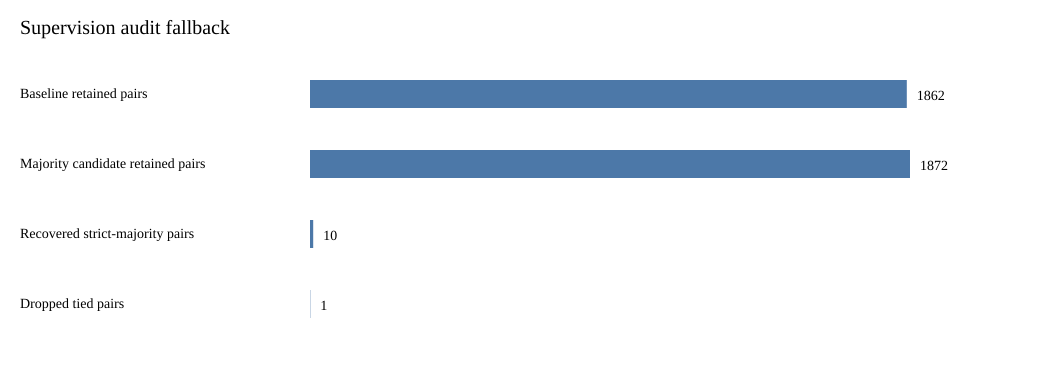

In [2]:
labels = ["Baseline retained pairs", "Majority candidate retained pairs", "Recovered strict-majority pairs", "Dropped tied pairs"]
values = [audit["baseline_retained_pairs"], audit["candidate_retained_pairs"], audit["resolved_majority_pairs"], audit["discarded_tie_pairs"]]
pio.templates.default = "none"
fig = go.Figure(go.Bar(x=values, y=labels, orientation="h", text=values, textposition="outside"))
fig.update_layout(title="One-factor supervision change: 10 recovered pairs, one tie still excluded", height=390, margin=dict(l=265, r=70, t=75, b=60), xaxis_title="Unique normalized rule/comment pairs", yaxis=dict(autorange="reversed", automargin=True), showlegend=False)
display(fig)
maxv=max(values)
rows=[]
for i,(label,value) in enumerate(zip(labels,values)):
    y=80+i*70; width=600*value/maxv if maxv else 0
    rows += [f'<text x="20" y="{y+18}" font-size="14">{label}</text>', f'<rect x="310" y="{y}" width="{width:.1f}" height="28" fill="#4C78A8"/>', f'<text x="{320+width:.1f}" y="{y+20}" font-size="14">{value}</text>']
svg='<svg xmlns="http://www.w3.org/2000/svg" width="1050" height="390" viewBox="0 0 1050 390"><rect width="1050" height="390" fill="white"/><text x="20" y="34" font-size="20">Supervision audit fallback</text>'+''.join(rows)+'</svg>'
display(SVG(svg))

In [3]:
for row in audit["folds"]:
    print(f"{row['policy']}: queries={row['query_rows']}, baseline_pairs={row['baseline_pairs']}, candidate_pairs={row['candidate_pairs']}, recovered={row['recovered_pairs']}, purge_passed={row['purge_passed']}")
assert all(row["purge_passed"] for row in audit["folds"])
assert audit["uncontested_label_parity"] is True
assert audit["forbidden_text_occurrences"] == 0
print("Leakage/purge checks passed for both policy folds.")
print("PLOTLY_SENTINEL_COMPLETE")

Advertising: queries=234, baseline_pairs=1640, candidate_pairs=1642, recovered=2, purge_passed=True
Legal advice: queries=647, baseline_pairs=1215, candidate_pairs=1224, recovered=9, purge_passed=True
Leakage/purge checks passed for both policy folds.
PLOTLY_SENTINEL_COMPLETE


## Competitive position and decision

The repository keeps the **0.91425 private-AUC support-adapted 4B model as the verified best**. The majority candidate is not promoted from a successful preview, recovered supervision, or a pending leaderboard entry.

The useful capability gained in this round is **a reproducible, one-factor end-to-end test of conflict supervision with leakage-safe query purging, durable preview evidence, duplicate-submission prevention, and an auditable Kaggle handoff**. If the official score does not improve, the direction stops. If it does improve, it still requires validation and error analysis before broader adoption.

The next higher-value frontier is stronger backbone capacity and complementary-model diversity—especially a bounded 14B comparison—rather than another broad expansion of raw feature columns.

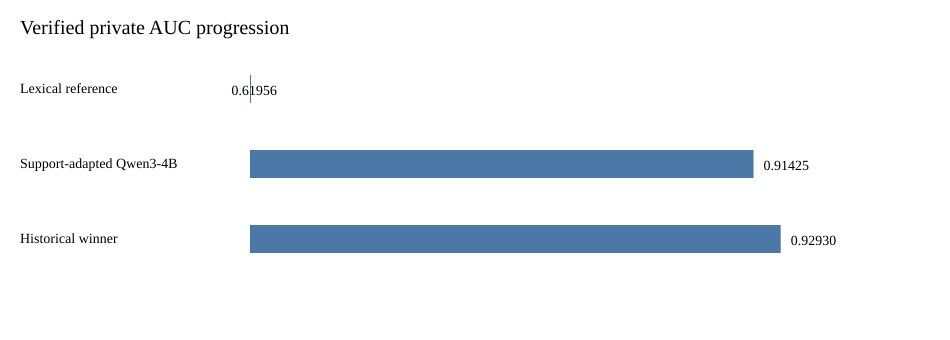

{
  "submission_ref": "56444879",
  "status_as_of_utc": "2026-09-21T23:08:21.271489+00:00",
  "automatic_promotion": false,
  "new_remote_previews_during_reconciliation": 0,
  "new_remote_submissions_during_reconciliation": 0,
  "model_fits_during_reconciliation": 0
}
LATEST_CHECKPOINT_COMPLETE


In [4]:
names=["Lexical reference","Support-adapted Qwen3-4B","Historical winner"]
private_auc=[0.61956, scored["private_auc"], scored["winning_private_auc"]]
fig2=go.Figure(go.Bar(x=private_auc,y=names,orientation="h",text=[f"{x:.5f}" for x in private_auc],textposition="outside"))
fig2.update_layout(title="Verified private-leaderboard progression; majority candidate remains unscored",height=340,margin=dict(l=235,r=70,t=75,b=60),xaxis_title="Private ROC AUC",xaxis_range=[0.58,0.94],yaxis=dict(autorange="reversed",automargin=True),showlegend=False)
display(fig2)
scale=lambda x: 150+650*(x-0.58)/(0.94-0.58)
rows=[]
for i,(name,value) in enumerate(zip(names,private_auc)):
    y=75+i*75; x2=scale(value)
    rows += [f'<text x="20" y="{y+18}" font-size="14">{name}</text>', f'<rect x="250" y="{y}" width="{max(1,x2-250):.1f}" height="28" fill="#4C78A8"/>', f'<text x="{x2+10:.1f}" y="{y+20}" font-size="14">{value:.5f}</text>']
svg2='<svg xmlns="http://www.w3.org/2000/svg" width="950" height="340" viewBox="0 0 950 340"><rect width="950" height="340" fill="white"/><text x="20" y="34" font-size="20">Verified private AUC progression</text>'+''.join(rows)+'</svg>'
display(SVG(svg2))
checks=summary["preview_and_reconciliation"] | summary["notebook_gate"]
for key in ["finite","id_order_passed","local_remote_audit_parity","save_reopen_verified","next_cell_sentinel_verified"]:
    assert checks[key] is True
assert candidate["automatic_promotion"] is False
print(json.dumps({"submission_ref":candidate["submission_ref"],"status_as_of_utc":candidate["status_as_of_utc"],"automatic_promotion":candidate["automatic_promotion"],"new_remote_previews_during_reconciliation":checks["new_remote_previews_during_reconciliation"],"new_remote_submissions_during_reconciliation":checks["new_remote_submissions_during_reconciliation"],"model_fits_during_reconciliation":checks["model_fits_during_reconciliation"]},indent=2))
print("LATEST_CHECKPOINT_COMPLETE")